In [1]:
import os
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio
from PIL import Image
import cv2

from transformers import AutoProcessor, Qwen3VLForConditionalGeneration



In [2]:

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = get_device()

MODEL_NAME = "Qwen/Qwen3-VL-2B-Instruct"  # change if you use another variant

print(f"Loading model {MODEL_NAME} on {DEVICE}...")

processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)

# dtype: float16 on GPU/MPS, float32 on CPU
dtype = torch.float16 if DEVICE in ("cuda", "mps") else torch.float32

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
    trust_remote_code=True,
)
model.to(DEVICE)
model.eval()

Loading model Qwen/Qwen3-VL-2B-Instruct on mps...


`torch_dtype` is deprecated! Use `dtype` instead!


Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1024)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (linear_fc2): Linear(in_features=4096, out_features=1024, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )
 

In [264]:

IMAGE_PATH = "image.png"  # <-- change to your image path
IMAGE_PATH = "img2.png"
IMAGE_PATH = "water.png"
# IMAGE_PATH = 'sushi.png'
IMAGE_PATH = 'BUS.png'
IMAGE_PATH = 'cycle.png'
IMAGE_PATH = 'graph.png'

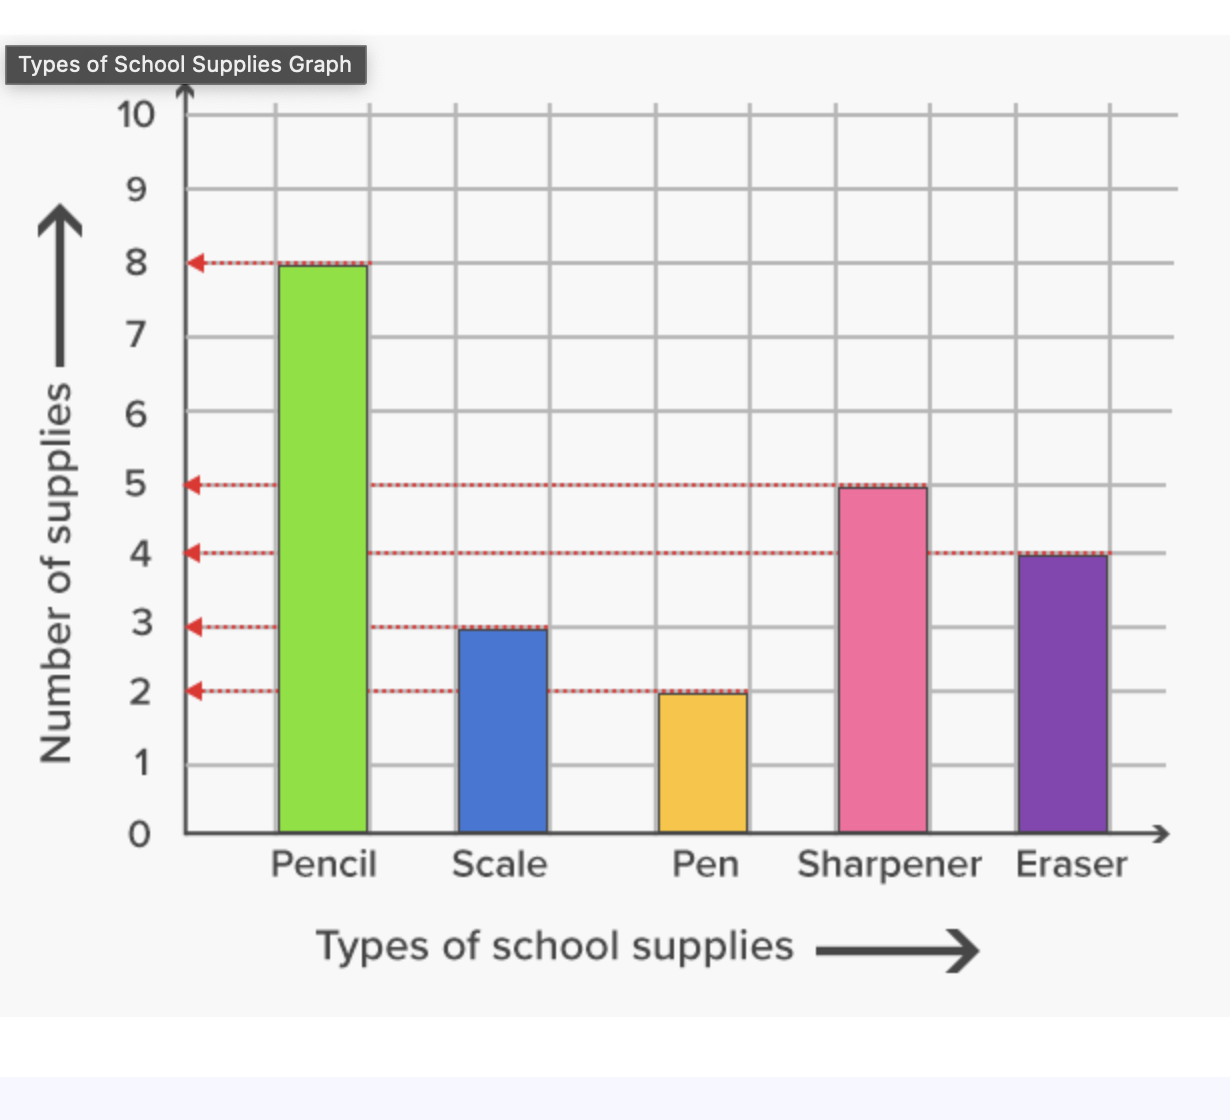

In [265]:



def load_image(path: str) -> Image.Image:
    img = Image.open(path).convert("RGB")
    return img


raw_image = load_image(IMAGE_PATH)

raw_image

In [266]:
raw_image.size

(1230, 1120)

In [267]:
raw_image = raw_image.resize((200,300))

In [268]:
raw_image.size

(200, 300)

In [269]:


def build_chat_inputs(image, prompt):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs.pop("token_type_ids", None)
    return inputs.to(DEVICE)


# -------------------------------------------------------
# GENERATE CAPTION + HIDDEN STATES
# -------------------------------------------------------

def generate_caption_and_hidden_states(image, prompt, max_new_tokens=20):
    base_inputs = build_chat_inputs(image, prompt)
    prompt_len = base_inputs["input_ids"].shape[1]

    # Generate caption
    with torch.no_grad():
        sequences = model.generate(
            **base_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=processor.tokenizer.eos_token_id,
        )

    full_ids = sequences[0]

    # Extract assistant-only response
    decoded = processor.tokenizer.decode(
        full_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )
    m = re.search(r"assistant\s*(.*)", decoded, flags=re.DOTALL | re.IGNORECASE)
    caption_text = m.group(1).strip() if m else decoded.strip()

    # SECOND PASS to get hidden states
    full_ids_batch = full_ids.unsqueeze(0).to(DEVICE)
    attention_mask = torch.ones_like(full_ids_batch)

    img_inputs = processor.image_processor(image, return_tensors="pt")
    pixel_values = img_inputs["pixel_values"].to(DEVICE)
    image_grid_thw = img_inputs["image_grid_thw"].to(DEVICE)

    with torch.no_grad():
        outputs = model(
            input_ids=full_ids_batch,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            image_grid_thw=image_grid_thw,
            output_hidden_states=True,
            use_cache=False,
        )

    # hidden_states_last = outputs.hidden_states[-1][0]

    # return caption_text, full_ids, hidden_states_last, pixel_values, image_grid_thw, prompt_len
    layer_index = 6  # You can try 4, 6, 8

    hidden_states_early = outputs.hidden_states[layer_index][0]  # [seq_len, hidden]
    return caption_text, full_ids, hidden_states_early, pixel_values, image_grid_thw, prompt_len


from pydoc import describe
import re

caption, full_ids, hidden_last, pixel_values, image_grid_thw, prompt_len = (
        generate_caption_and_hidden_states(
            raw_image,
            # prompt="Describe this image using at most 8 words.",
            # prompt="Describe the sequence of events briefly at most 10 words.",
            prompt = "describe the chart  briefly at most 20 words.",
            max_new_tokens=40,
        )
    )

In [270]:
caption


'A bar graph shows the number of school supplies for five types: Pencil, Scale, Pen, Sharpener, and Eraser. The number of supplies ranges from 7 to 8.'

In [271]:

def get_image_patch_embeddings(pixel_values, image_grid_thw):
    image_embs_list, deepstack = model.get_image_features(
        pixel_values=pixel_values,
        image_grid_thw=image_grid_thw,
    )

    # Single image → index 0
    image_embs = image_embs_list[0]  # shape [70, hidden]

    T, H, W = image_grid_thw[0].tolist()
    spatial = model.visual.spatial_merge_size  # = 2

    H_patches = H // spatial  # 14/2 = 7
    W_patches = W // spatial  # 20/2 = 10

    expected = H_patches * W_patches
    assert expected == image_embs.shape[0], "Unexpected patch count mismatch."

    return image_embs, H_patches, W_patches

image_embs, H_patches, W_patches = get_image_patch_embeddings(
        pixel_values, image_grid_thw
    )

In [272]:

def compute_similarity(hidden_states_last, full_ids, prompt_len, image_embs):
    total_len = hidden_states_last.shape[0]

    gen_positions = list(range(prompt_len, total_len))
    gen_token_ids = full_ids[prompt_len:]

    tokens = [
        processor.tokenizer.decode([tid], skip_special_tokens=True)
        for tid in gen_token_ids.tolist()
    ]
    tokens = [t for t in tokens if t.strip()]

    # Normalize image patch embeddings
    img_norm = image_embs / (image_embs.norm(dim=-1, keepdim=True) + 1e-6)

    sim_vectors = []
    for pos in gen_positions:
        token_vec = hidden_states_last[pos]
        token_norm = token_vec / (token_vec.norm(dim=-1, keepdim=True) + 1e-6)
        sim = torch.matmul(img_norm, token_norm)
        sim_vectors.append(sim.detach().cpu().numpy())

    # Match count
    if len(sim_vectors) > len(tokens):
        sim_vectors = sim_vectors[:len(tokens)]

    return sim_vectors, tokens
sim_vectors, tokens = compute_similarity(
        hidden_states_last=hidden_last,
        full_ids=full_ids,
        prompt_len=prompt_len,
        image_embs=image_embs,
    )

print("Tokens:", tokens)
print("Grid:", H_patches, "x", W_patches)


Tokens: ['A', ' bar', ' graph', ' shows', ' the', ' number', ' of', ' school', ' supplies', ' for', ' five', ' types', ':', ' P', 'encil', ',', ' Scale', ',', ' Pen', ',', ' Sharp', 'ener', ',', ' and', ' Er', 'aser', '.', ' The', ' number', ' of', ' supplies', ' ranges', ' from', '7', ' to', '8', '.']
Grid: 10 x 7


In [273]:


# -------------------------------------------------------
# HEATMAP FUNCTIONS
# -------------------------------------------------------

def normalize_grid(x):
    x = x - x.min()
    m = x.max()
    return x / m if m > 0 else x

def overlay_heatmap(image, grid, alpha=0.5):
    img = np.array(image.convert("RGB"))
    H, W, _ = img.shape

    grid = normalize_grid(grid)
    # heat = cv2.resize(grid, (W, H), interpolation=cv2.INTER_CUBIC)
    grid = np.ascontiguousarray(grid.astype(np.float32))

    heat = cv2.resize(grid, (W, H), interpolation=cv2.INTER_CUBIC)
    heat = normalize_grid(heat)

    cmap = plt.get_cmap("jet")
    heat_rgb = cmap(heat)[:, :, :3]

    blended = (1-alpha) * (img/255.0) + alpha * heat_rgb
    blended = (blended*255).astype(np.uint8)
    return Image.fromarray(blended)

def render_caption_with_highlight(tokens, current_index):
    """
    Returns a list of (token_text, color) pairs.
    All tokens are gray, current token is red.
    """
    rendered = []
    for i, tok in enumerate(tokens):
        color = "red" if i == current_index else "gray"
        rendered.append((tok, color))
    return rendered
def draw_colored_caption(fig, tokens, current_idx):
    """
    Draws the full caption above the image.
    All tokens in gray except the current one in red.
    """
    x = 0.01                 # caption left margin
    y = 0.98                 # vertical position (top of figure)
    spacing = 0.015          # horizontal spacing between tokens

    for i, tok in enumerate(tokens):
        color = "red" if i == current_idx else "gray"

        fig.text(
            x,
            y,
            tok,
            color=color,
            fontsize=14,
            ha="left",
            va="top",
        )
        # move x to the right based on token width
        x += (len(tok) * spacing)
def draw_pretty_caption(fig, caption_tokens, current_idx):
    """
    Draws a clean centered caption bar with perfect spacing.
    Uses real text width, so no overlaps happen.
    """

    # Background bar
    fig.patches.extend([
        plt.Rectangle(
            (0, 0.90),  # x, y (figure coords)
            1.0,        # width
            0.10,       # height
            transform=fig.transFigure,
            color="white",
            zorder=-1,
        )
    ])

    # --- Step 1: measure widths using a dummy renderer ---
    renderer = fig.canvas.get_renderer()

    fontsize = 18
    space = 0.015  # relative space between tokens

    token_widths = []
    for i, tok in enumerate(caption_tokens):
        txt = fig.text(
            0, 0, tok,
            fontsize=fontsize,
            fontweight="bold" if i == current_idx else "regular",
        )
        bb = txt.get_window_extent(renderer=renderer)
        txt.remove()
        token_widths.append(bb.width)

    # Compute total width in figure coordinates
    fig_width_px = fig.get_figwidth() * fig.dpi
    total_px = sum(token_widths) + (len(caption_tokens)-1)*space*fig_width_px

    # Convert to figure coords
    total_fig_w = total_px / fig_width_px

    # Start centered
    x = 0.5 - total_fig_w/2
    y = 0.95

    # --- Step 2: actually draw the caption ---
    for i, tok in enumerate(caption_tokens):
        color = "red" if i == current_idx else "gray"
        weight = "bold" if i == current_idx else "regular"

        fig.text(
            x,
            y,
            tok,
            fontsize=fontsize,
            color=color,
            weight=weight,
            ha="left",
            va="center",
        )

        # Move x by token width (in figure coords)
        x += token_widths[i] / fig_width_px
        x += space
def draw_pretty_caption_wrapped(fig, caption_tokens, current_idx, max_width_px=None):
    """
    Wraps tokens into multiple centered lines so text never overflows.
    Uses fig size + dpi to compute available width.
    """

    renderer = fig.canvas.get_renderer()
    fontsize = 18
    space_px = 12  # pixel spacing between tokens

    # Determine available width in pixels
    fig_width_px = fig.get_figwidth() * fig.dpi
    if max_width_px is None:
        max_width_px = fig_width_px * 0.90  # safe margin

    # ---- Measure each token ----
    measured = []
    for i, tok in enumerate(caption_tokens):
        txt = fig.text(0, 0, tok, fontsize=fontsize)
        bb = txt.get_window_extent(renderer=renderer)
        txt.remove()
        measured.append((tok, bb.width))

    # ---- Build wrapped lines ----
    lines = []
    current_line = []
    current_width = 0

    for i, (tok, w) in enumerate(measured):
        extra = w if not current_line else (space_px + w)
        if current_width + extra > max_width_px:
            lines.append(current_line)
            current_line = [(tok, w, i)]
            current_width = w
        else:
            current_line.append((tok, w, i))
            current_width += extra

    if current_line:
        lines.append(current_line)

    # ---- Draw background bar ----
    fig.patches.extend([
        plt.Rectangle(
            (0, 0.88 - 0.05*len(lines)),  # height scales with number of lines
            1.0,
            0.12 + 0.05*len(lines),
            transform=fig.transFigure,
            color="white",
            zorder=-1,
        )
    ])

    # ---- Draw wrapped lines ----
    y_start = 0.94
    line_spacing = 0.05

    for li, line in enumerate(lines):
        total_w = sum(w for _, w, _ in line) + space_px * (len(line) - 1)
        total_fig_w = total_w / fig_width_px

        x = 0.5 - total_fig_w / 2
        y = y_start - li * line_spacing

        for tok, w, token_index in line:
            color = "red" if token_index == current_idx else "gray"
            weight = "bold" if token_index == current_idx else "regular"

            fig.text(
                x,
                y,
                tok,
                fontsize=fontsize,
                color=color,
                weight=weight,
                ha="left",
                va="center",
            )
            x += (w + space_px) / fig_width_px


def build_frames(
    image,
    tokens,
    sim_vectors,
    H_patches,
    W_patches,
    out_dir="frames",
    alpha=0.5,
):
    os.makedirs(out_dir, exist_ok=True)
    frames = []

    for i in range(len(tokens)):
        vec = sim_vectors[i]
        grid = vec.reshape(H_patches, W_patches)

        frame_img = overlay_heatmap(image, grid, alpha=alpha)

        fig, ax = plt.subplots(figsize=(6, 7))
        fig.subplots_adjust(top=0.82)

        # show heatmap+image
        ax.imshow(frame_img)
        ax.axis("off")

        # ----- NEW COLORED CAPTION -----
        # draw_colored_caption(fig, tokens, i)
        # ----- improved centered caption -----
        # draw_pretty_caption(fig, tokens, i)
        draw_pretty_caption_wrapped(fig, tokens, i)

        # save frame
        fname = f"{out_dir}/frame_{i:02d}.png"
        # plt.savefig(fname, bbox_inches="tight", dpi=120)
        plt.savefig(fname, dpi=120, pad_inches=0.2)
        plt.close(fig)

        frames.append(fname)

    return frames


def make_gif(frames, out="attention.gif", duration=0.7):
    imgs = [imageio.imread(f) for f in frames]
    imageio.mimsave(out, imgs, duration=duration)
    print("GIF saved to:", out)


frames = build_frames(raw_image, tokens, sim_vectors, H_patches, W_patches)
make_gif(frames, out=IMAGE_PATH+"attention.gif")

/var/folders/d2/437bvc8d01b_3qrdk4rtdxk00000gp/T/ipykernel_89491/2725564286.py:250: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imgs = [imageio.imread(f) for f in frames]


GIF saved to: graph.pngattention.gif


In [274]:
Image.open(frames[0]).size,Image.open(frames[2]).size

((720, 840), (720, 840))